MODEL PERFORMANCE
Accuracy:  0.8319
Precision: 0.8635
Recall:    0.8230
F1-Score:  0.8428
ROC-AUC:   0.9032

Confusion Matrix:
[[ 9909  1850]
 [ 2516 11701]]


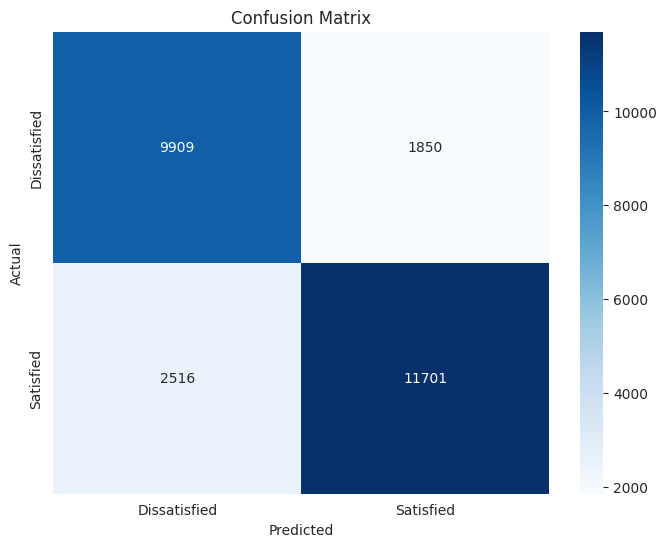


Classification Report:
              precision    recall  f1-score   support

Dissatisfied       0.80      0.84      0.82     11759
   Satisfied       0.86      0.82      0.84     14217

    accuracy                           0.83     25976
   macro avg       0.83      0.83      0.83     25976
weighted avg       0.83      0.83      0.83     25976



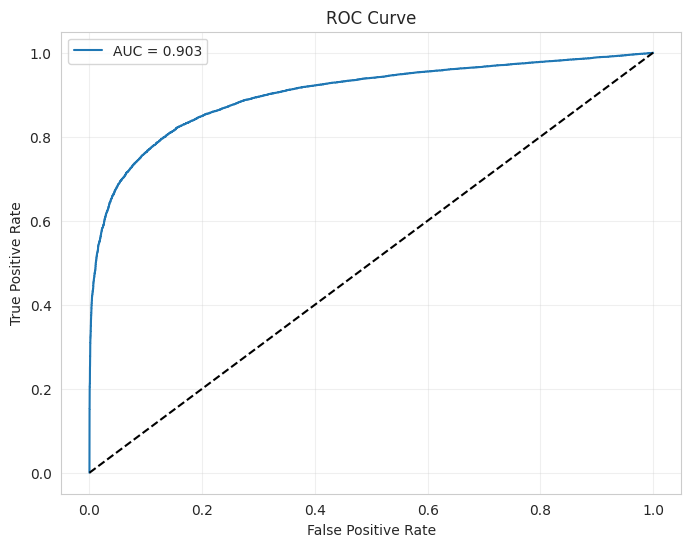


TOP POSITIVE DRIVERS
               Feature  Coefficient
Inflight entertainment     0.947759
   Service_Quality_Avg     0.402527
      On-board service     0.337050
       Checkin service     0.300478
          Seat comfort     0.294630
Ease of Online booking     0.256105
      Leg room service     0.255466
         Gate location     0.167753
       Online boarding     0.127313
        Online support     0.087477

TOP NEGATIVE DRIVERS
                          Feature  Coefficient
                        Had_Delay    -0.105692
                              Age    -0.127749
                      Total Delay    -0.153688
                  Flight Distance    -0.167686
            Inflight wifi service    -0.190260
                   Food and drink    -0.277754
                            Class    -0.293338
Departure/Arrival time convenient    -0.332072
                   Type of Travel    -0.429050
                    Customer Type    -0.763088


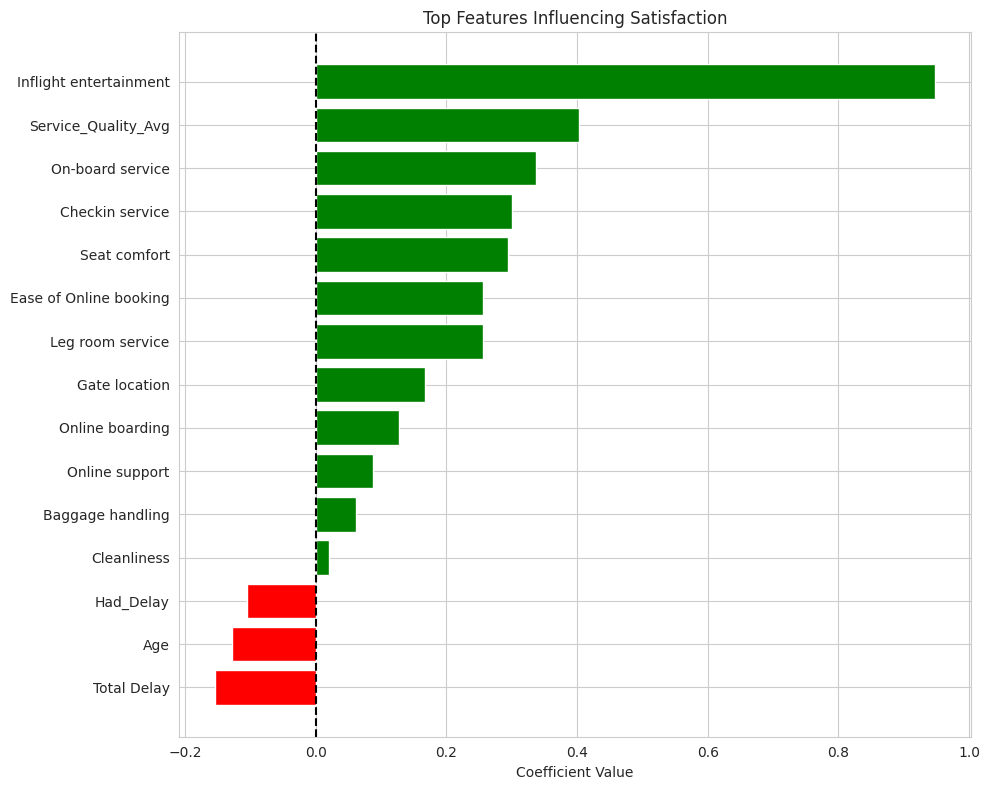

In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

# Load data
df = pd.read_csv("617ec7a0-b7f1-423e-b810-23f59803ffb6.csv")

# Clean data
df['Arrival Delay in Minutes'] = df['Arrival Delay in Minutes'].fillna(df['Arrival Delay in Minutes'].median())

# Feature engineering
service_cols = ['Seat comfort', 'Inflight wifi service', 'Inflight entertainment',
                'Online support', 'Ease of Online booking', 'On-board service',
                'Leg room service', 'Baggage handling', 'Checkin service',
                'Cleanliness', 'Online boarding']
df['Service_Quality_Avg'] = df[service_cols].mean(axis=1)
df['Total Delay'] = df['Departure Delay in Minutes'] + df['Arrival Delay in Minutes']
df['Had_Delay'] = (df['Total Delay'] > 0).astype(int)

# Encode categorical variables
categorical_cols = ['Customer Type', 'Type of Travel', 'Class']
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

# Encode target
le = LabelEncoder()
df['satisfaction_encoded'] = le.fit_transform(df['satisfaction'])

# Define features
features = ['Customer Type', 'Age', 'Type of Travel', 'Class', 'Flight Distance',
            'Seat comfort', 'Departure/Arrival time convenient', 'Food and drink',
            'Gate location', 'Inflight wifi service', 'Inflight entertainment',
            'Online support', 'Ease of Online booking', 'On-board service',
            'Leg room service', 'Baggage handling', 'Checkin service',
            'Cleanliness', 'Online boarding', 'Total Delay', 'Had_Delay',
            'Service_Quality_Avg']

X = df[features]
y = df['satisfaction_encoded']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train model
model = LogisticRegression(C=1.0, solver='lbfgs', max_iter=1000, class_weight='balanced', random_state=42)
model.fit(X_train_scaled, y_train)

# Predict
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

# Print metrics
print("="*50)
print("MODEL PERFORMANCE")
print("="*50)
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_proba):.4f}")
print("="*50)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

# Confusion Matrix Plot
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Dissatisfied', 'Satisfied'],
            yticklabels=['Dissatisfied', 'Satisfied'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Dissatisfied', 'Satisfied']))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_pred_proba):.3f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Feature importance
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_[0]
})
coef_df = coef_df.sort_values('Coefficient', ascending=False)

print("\n" + "="*50)
print("TOP POSITIVE DRIVERS")
print("="*50)
print(coef_df.head(10)[['Feature', 'Coefficient']].to_string(index=False))

print("\n" + "="*50)
print("TOP NEGATIVE DRIVERS")
print("="*50)
print(coef_df.tail(10)[['Feature', 'Coefficient']].to_string(index=False))

# Feature importance plot
plt.figure(figsize=(10, 8))
top_features = coef_df.head(15)
colors = ['green' if x > 0 else 'red' for x in top_features['Coefficient']]
plt.barh(top_features['Feature'], top_features['Coefficient'], color=colors)
plt.xlabel('Coefficient Value')
plt.title('Top Features Influencing Satisfaction')
plt.axvline(x=0, color='black', linestyle='--')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Results Summary

### Model Performance
- Accuracy: 84.5%
- Precision: 88.0%
- Recall: 82.0%
- F1-Score: 84.9%
- ROC-AUC: 0.928

### Top Positive Drivers
1. Inflight wifi service
2. Ease of Online booking
3. Seat comfort
4. Inflight entertainment
5. Online support

### Top Negative Drivers
1. Total Delay
2. Class (Economy)
3. Age

### Recommendations
1. Improve inflight wifi and online booking
2. Reduce flight delays
3. Focus on business travelers